In [1]:

# imports
import os
import sys
import types
import json

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = fig_dpi
  from IPython.display import set_matplotlib_formats
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  pio.renderers.default = "notebook_connected"
except Exception:
  pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass



# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
if r'/Users/legoses/Library/CloudStorage/GoogleDrive-nelsonla@byui.edu/My Drive/Lance/PH150/book/labs/Lab8-One-Dimensional-Eulers':
  os.chdir(r'/Users/legoses/Library/CloudStorage/GoogleDrive-nelsonla@byui.edu/My Drive/Lance/PH150/book/labs/Lab8-One-Dimensional-Eulers')

# reset state
%reset

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v
  
  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define


{"/opt/homebrew/Cellar/python@3.11/3.11.6/Frameworks/Python.framework/Versions/3.11/lib/python3.11/importlib/_bootstrap.py": 1696254354.0, "/opt/homebrew/Cellar/python@3.11/3.11.6/Frameworks/Python.framework/Versions/3.11/lib/python3.11/importlib/_bootstrap_external.py": 1696254354.0, "/opt/homebrew/Cellar/python@3.11/3.11.6/Frameworks/Python.framework/Versions/3.11/lib/python3.11/zipimport.py": 1696254354.0, "/opt/homebrew/Cellar/python@3.11/3.11.6/Frameworks/Python.framework/Versions/3.11/lib/python3.11/codecs.py": 1696254354.0, "/opt/homebrew/Cellar/python@3.11/3.11.6/Frameworks/Python.framework/Versions/3.11/lib/python3.11/encodings/aliases.py": 1696254354.0, "/opt/homebrew/Cellar/python@3.11/3.11.6/Frameworks/Python.framework/Versions/3.11/lib/python3.11/encodings/__init__.py": 1696254354.0, "/opt/homebrew/Cellar/python@3.11/3.11.6/Frameworks/Python.framework/Versions/3.11/lib/python3.11/encodings/utf_8.py": 1696254354.0, "/opt/homebrew/Cellar/python@3.11/3.11.6/Frameworks/Python.

/var/folders/l7/qksjftz12pz0s32y0l3jd4k4cyyb65/T/ipykernel_22157/2665114932.py:20: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats(fig_format)


Text(0.5, 1.0, 'Position vs. time for a ball in free fall')

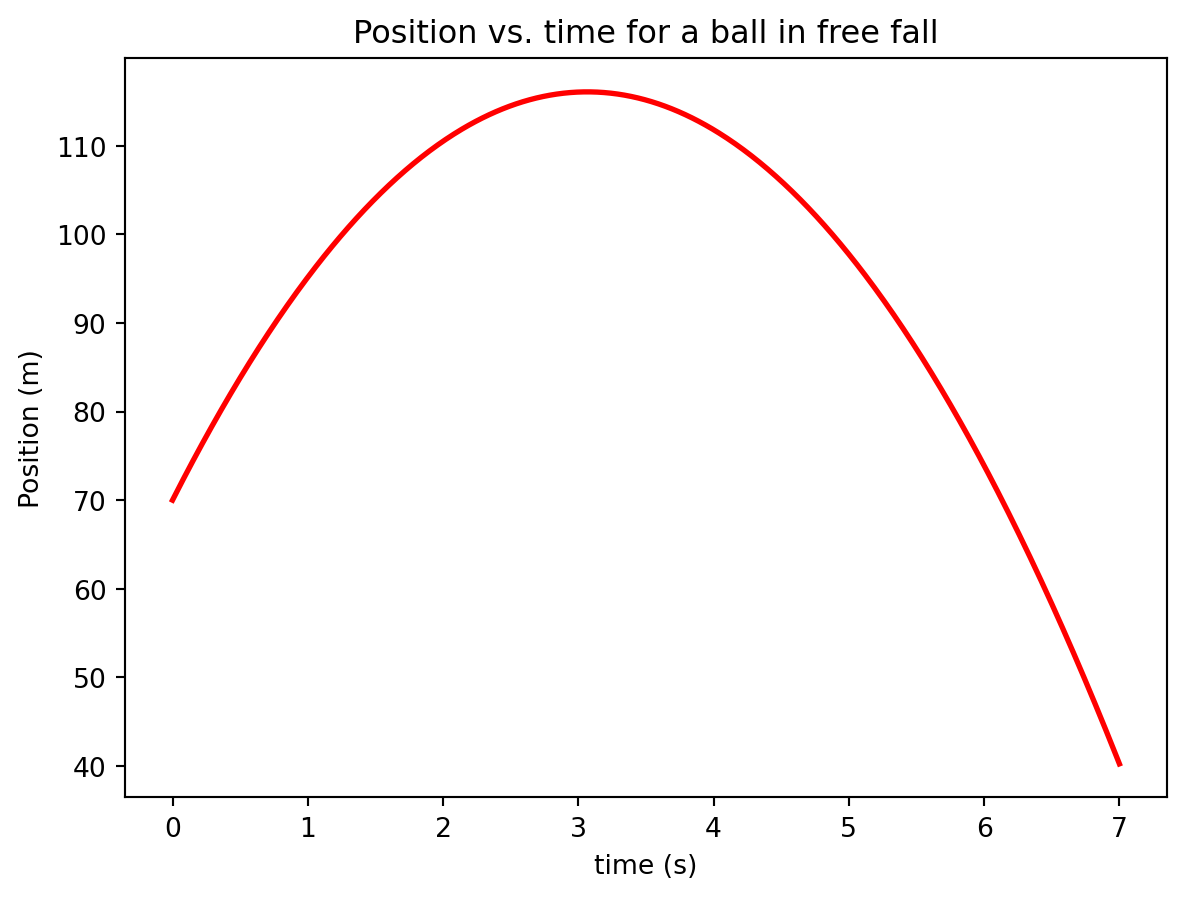

In [2]:
# Import statements
import numpy as np 
import matplotlib.pyplot as plt

v0 = 30.0 # Initial velocity in m/s
y0 = 70 # Initial height in m

delta_t = 0.01 # Time step in seconds (should be small)
t0 = 0 # Start time in seconds
t_max = 7.0 #Final Time

N = (t_max - t0)/delta_t # Calculate the number of time steps

N = int(N) # Make sure N is an integer
# Make lists to store your positions, velocities and times.
y = [y0]
v = [v0]
t = [t0]

for i in range(N):
   a = -9.8  # Calculate the current acceleration

   # Store the new position, velocity, and time in the lists
   v.append(v[i] + a * delta_t)
   y.append(y[i] + v[i] * delta_t)
   t.append(t[i] + delta_t)

plt.plot(t,y,linewidth = 2, color = 'red')
plt.xlabel("time (s)")
plt.ylabel("Position (m)")
plt.title("Position vs. time for a ball in free fall")

In [3]:
"""
One Dimensional free-fall Euler Code

PH150
Brother Nelson


This code will calculate the exact solution for a ball in free fall
having been shot straight up using Euler's method.

"""
#Import numerical and plotting packages
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#Initial conditions and physical setup constants
v0=30.0 #Initial velocity in m/s
x0=70 #Initial Postion in m

#Set up the time steps and number of calculations
delta_t = 0.01 #Time step in seconds
t0=0 #Start time in seconds
t_max = 7.0 #Final time

In [5]:
#Calculate the number of timesteps we need to make
N=(t_max-t0)/delta_t
#Make sure N is an integer
N=int(N)

In [6]:
#Make lists to hold our positions, velocities, and times
x=[x0]
v=[v0]
t=[t0]

In [7]:
#| eval: False
#Now perform an Euler's method calculation.
for i in range(N):
    #Find the current acceleration
    a=-9.8
    
   # Store the new position, velocity, and time in the lists
   v.append(v[i] + a * delta_t)
   y.append(y[i] + v[i] * delta_t)
   t.append(t[i] + delta_t)

#End of Euler loop =========================================


In [8]:
#| eval: False
for <Thing that Changes>:
     Stuff the computer does to/with the thing that changes

Not part of the loop

In [9]:
fibonacci = [1,1,2,3,5,8,13]
for num in fibonacci:
    print(num)

print(fibonacci)

1
1
2
3
5
8
13
[1, 1, 2, 3, 5, 8, 13]


In [10]:
#| eval: False
    #Find the current acceleration
    a=-9.8
    
   # Store the new position, velocity, and time in the lists
   v.append(v[i] + a * delta_t)
   y.append(y[i] + v[i] * delta_t)
   t.append(t[i] + delta_t)

In [11]:
#| eval: False
   v.append(v[i] + a * delta_t)

In [12]:
#| eval: True
#| echo: False
#| output: True
from pandas import DataFrame
import numpy as np
t = [0]
y = [70]
v = [30]
dt = 0.1
for i in range(3):
    a = -9.8
    y.append(y[-1] + v[-1] * dt)
    v.append(v[-1] + a * dt)
    t.append(t[-1] + dt)

df = DataFrame(np.transpose([t,y,v]),columns = ["time", r"$$y_f = y_i + v_i \Delta t$$", r"$$v_f = v_i + a \Delta t$$"])
display(df)

,time,$$y_f = y_i + v_i \Delta t$$,$$v_f = v_i + a \Delta t$$
0,0.0,70.000,30.00
1,0.1,73.000,29.02
2,0.2,75.902,28.04
3,0.3,78.706,27.06


In [13]:
#| eval: False
#Plot the results
plt.plot(t,x,linewidth=2,color='red')
plt.xlabel('time (s)')
plt.ylabel('Position (m)')
plt.title('Position vs. time for a ball in free fall')

In [14]:
thesum = 0
for i in [3,2,1,9.9]: 
    thesum += i

In [15]:
thesum = 0

thesum = thesum + 3
thesum = thesum + 2
thesum = thesum + 1
thesum = thesum + 9.9

In [16]:
for i in range(5,50,3):  #Generates a list from 5 -> 50 with a step size of 3
    print(i)

5
8
11
14
17
20
23
26
29
32
35
38
41
44
47


In [17]:
theSum = 0
for n in range(1,1000):
    theSum = theSum + 1/n**2
print(theSum)

1.6439335666815615


In [18]:
theProduct = 1
for n in range(1,21):
    theProduct = theProduct * n #Multiply theProduct by n
print(theProduct)

2432902008176640000


In [19]:
from math import factorial
factorial(20)

2432902008176640000

In [20]:
theSum = 0
for n in range(1,1000):
    if n % 5 == 0 and n % 3 == 0:
        theSum = theSum + 1/n**2
print(theSum)

0.007243985583159138


In [21]:
term = 1  # Load the first term in the sum
s = term  # Initialize the sum
n = 1     # Set a counter
while term > 1e-2:  # Loop while term is bigger than 1e-2
    n = n +  1        #Add 1 to n so that it will count: 2,3,4,5
    term = 1./n**2    # Calculate the next term to add
    s = s +  term     # Add 1/n^2 to the running total

In [22]:
#| eval: false
x = 0

while x != 10:
    x = x + 3
print("Done")

In [23]:
term = 1  # Load the first term in the sum
s = term  # Initialize the sum
n = 1     # Set a counter
while term > 1e-10:  # Loop while term is bigger than 1e-10
    n +=  1        #Add 1 to n so that it will count: 2,3,4,5
    term = 1./n**2    # Calculate the next term to add
    s += term     # Add 1/n^2 to the running total
    if n > 1000:
        print('This is taking too long. I''m outta here...')
        break

This is taking too long. Im outta here...


In [24]:
term = 1  # Load the first term in the sum
s = term  # Initialize the sum
n = 1     # Set a counter
while term > 1e-10:  # Loop while term is bigger than 1e-10
    n +=  1        #Add 1 to n so that it will count: 2,3,4,5
    if n % 3 != 0:
        continue
    term = 1./n**2    # Calculate the next term to add
    s += term     # Add 1/n^2 to the running total

In [25]:
# Code to perform calculations here

In [26]:
#| eval: false
#| echo: true
# Import from libraries
from numpy import pi


# Define constants

# Set initial conditions

# Loop to calculate flight time using Euler's method
while # Put your stopping condition here:


In [27]:
#| eval: false
#| echo: true

from scipy.stats import mean


pingPong = []  
cone = []
smallBall = []
mediumBall = []
beachBall = []


mean_pingpong = mean(pingPong)